# Notebook 3: Ewaluacja i analiza wyników

## Analiza sentymentu polskich recenzji produktów

W tym notebooku:
1. Porównujemy ilościowo oba podejścia (klasyczne vs Transformer)
2. Przeprowadzamy analizę błędów
3. Identyfikujemy typowe pomyłki modeli z przykładami
4. Formułujemy wnioski

## 1. Import i wczytanie wyników

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

In [3]:
# Wczytanie predykcji z Notebooka 2
results_df = pd.read_csv("test_predictions.csv")

with open("results_summary.pkl", "rb") as f:
    summary = pickle.load(f)

TEXT_COL = "text"
LABEL_COL = "sentiment"

y_true = results_df[LABEL_COL].values
y_pred_classic = results_df["pred_classic"].values
y_pred_transformer = results_df["pred_transformer"].values

print(f"Liczba próbek testowych: {len(results_df)}")
print(f"Podejście klasyczne: {summary['classic_name']}")
print(f"Podejście Transformer: {summary['transformer_name']}")

Liczba próbek testowych: 1500
Podejście klasyczne: SVM (LinearSVC)
Podejście Transformer: HerBERT


## 2. Porównanie ilościowe

In [4]:
# Tabela porównawcza metryk
metrics_data = []

for name, y_pred in [
    (summary["classic_name"], y_pred_classic),
    ("HerBERT (Transformer)", y_pred_transformer),
]:
    metrics_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1-score": f1_score(y_true, y_pred, average="weighted"),
    })

metrics_df = pd.DataFrame(metrics_data)
metrics_df = metrics_df.set_index("Model")

print("Porównanie metryk na zbiorze testowym:")
print("=" * 60)
print(metrics_df.round(4).to_string())
print("=" * 60)

Porównanie metryk na zbiorze testowym:
                       Accuracy  Precision  Recall  F1-score
Model                                                       
SVM (LinearSVC)          0.6847     0.6593  0.6847    0.6649
HerBERT (Transformer)    0.7280     0.7152  0.7280    0.7185


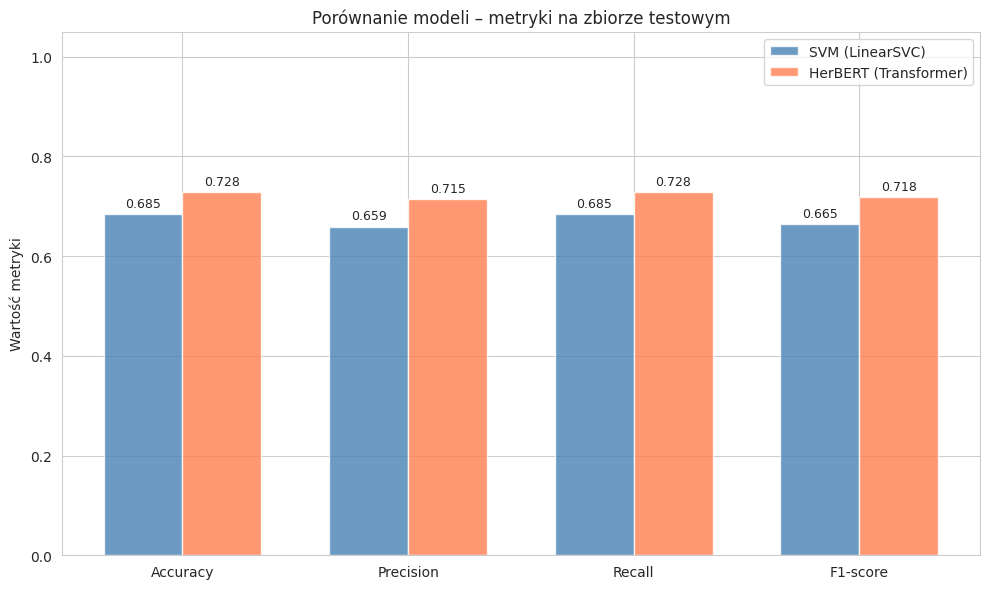

In [7]:
# Wykres porównawczy metryk
metrics_plot = metrics_df.T

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics_plot.index))
width = 0.35

bars1 = ax.bar(
    x - width / 2,
    metrics_plot.iloc[:, 0],
    width,
    label=metrics_plot.columns[0],
    color="steelblue",
    alpha=0.8,
)
bars2 = ax.bar(
    x + width / 2,
    metrics_plot.iloc[:, 1],
    width,
    label=metrics_plot.columns[1],
    color="coral",
    alpha=0.8,
)

ax.set_ylabel("Wartość metryki")
ax.set_title("Porównanie modeli – metryki na zbiorze testowym")
ax.set_xticks(x)
ax.set_xticklabels(metrics_plot.index)
ax.legend()
ax.set_ylim(0, 1.05)

# Wartości nad słupkami
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

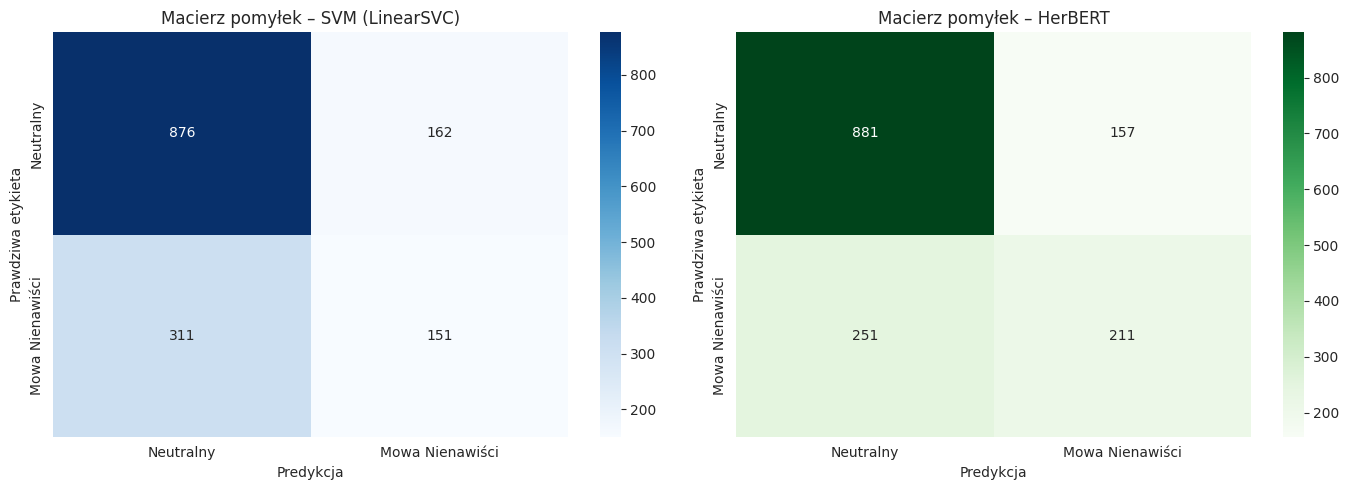

In [9]:
# Macierze pomyłek obok siebie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, y_pred, cmap) in enumerate([
    (summary["classic_name"], y_pred_classic, "Blues"),
    ("HerBERT", y_pred_transformer, "Greens"),
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        ax=axes[idx],
        xticklabels=["Neutralny", "Mowa Nienawiści"],
        yticklabels=["Neutralny", "Mowa Nienawiści"],
    )
    axes[idx].set_title(f"Macierz pomyłek – {name}")
    axes[idx].set_xlabel("Predykcja")
    axes[idx].set_ylabel("Prawdziwa etykieta")

plt.tight_layout()
plt.show()

In [11]:
# Szczegółowe raporty klasyfikacji
print(f"{'='*60}")
print(f"Raport klasyfikacji – {summary['classic_name']}")
print(f"{'='*60}")
print(classification_report(
    y_true, y_pred_classic, target_names=["Neutralny", "Mowa Nienawiści"]
))

print(f"\n{'='*60}")
print(f"Raport klasyfikacji – HerBERT")
print(f"{'='*60}")
print(classification_report(
    y_true, y_pred_transformer, target_names=["Neutralny", "Mowa Nienawiści"]
))

Raport klasyfikacji – SVM (LinearSVC)
                 precision    recall  f1-score   support

      Neutralny       0.74      0.84      0.79      1038
Mowa Nienawiści       0.48      0.33      0.39       462

       accuracy                           0.68      1500
      macro avg       0.61      0.59      0.59      1500
   weighted avg       0.66      0.68      0.66      1500


Raport klasyfikacji – HerBERT
                 precision    recall  f1-score   support

      Neutralny       0.78      0.85      0.81      1038
Mowa Nienawiści       0.57      0.46      0.51       462

       accuracy                           0.73      1500
      macro avg       0.68      0.65      0.66      1500
   weighted avg       0.72      0.73      0.72      1500



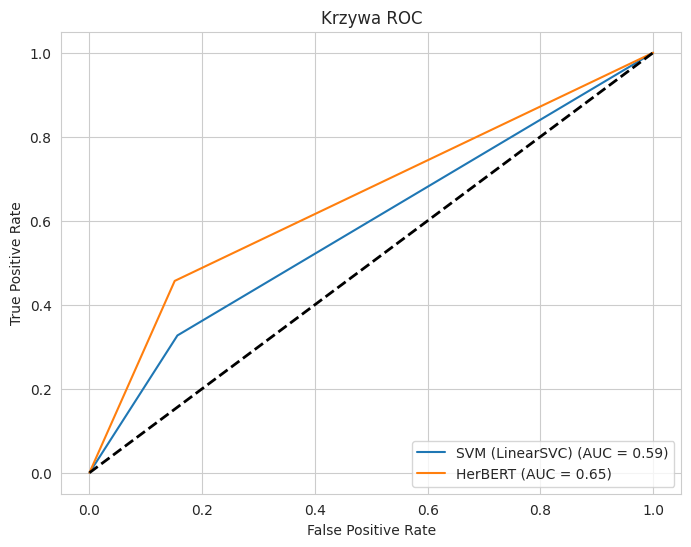

In [47]:
from sklearn.metrics import roc_curve, auc
# Krzywa ROC (Receiver Operating Characteristic) to wykres pokazujący zdolność klasyfikatora
# do rozróżniania klas przy różnych progach odcięcia prawdopodobieństwa.
plt.figure(figsize=(8, 6))
# - Oś X (False Positive Rate): Odsetek przypadków neutralnych błędnie uznanych za mowę nienawiści.
# - Oś Y (True Positive Rate): Odsetek poprawnie wykrytej mowy nienawiści (czułość).
# - Pole pod krzywą (AUC - Area Under Curve) mówi nam, jak dobry jest model:
#   1.0 to ideał, 0.5 to zgadywanie losowe.
for name, y_pred in [(summary["classic_name"], y_pred_classic), ("HerBERT", y_pred_transformer)]:
    # 1. Obliczamy wartości dla różnych progów
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    # 2. Obliczamy pole pod krzywą (AUC)
    roc_auc = auc(fpr, tpr)
    # 3. Rysujemy krzywą
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("roc_curve.png")

## 3. Analiza błędów

In [13]:
# Identyfikacja błędnych predykcji
results_df["classic_correct"] = (y_true == y_pred_classic)
results_df["transformer_correct"] = (y_true == y_pred_transformer)

# Kategorie błędów
results_df["error_type"] = "oba poprawne"
results_df.loc[
    ~results_df["classic_correct"] & results_df["transformer_correct"],
    "error_type"
] = "tylko klasyczny błędny"
results_df.loc[
    results_df["classic_correct"] & ~results_df["transformer_correct"],
    "error_type"
] = "tylko transformer błędny"
results_df.loc[
    ~results_df["classic_correct"] & ~results_df["transformer_correct"],
    "error_type"
] = "oba błędne"

print("Kategorie błędów:")
error_counts = results_df["error_type"].value_counts()
print(error_counts)
print(f"\nProcent zgodności obu modeli: {(error_counts.get('oba poprawne', 0)) / len(results_df) * 100:.1f}%")

Kategorie błędów:
error_type
oba poprawne                891
oba błędne                  272
tylko klasyczny błędny      201
tylko transformer błędny    136
Name: count, dtype: int64

Procent zgodności obu modeli: 59.4%


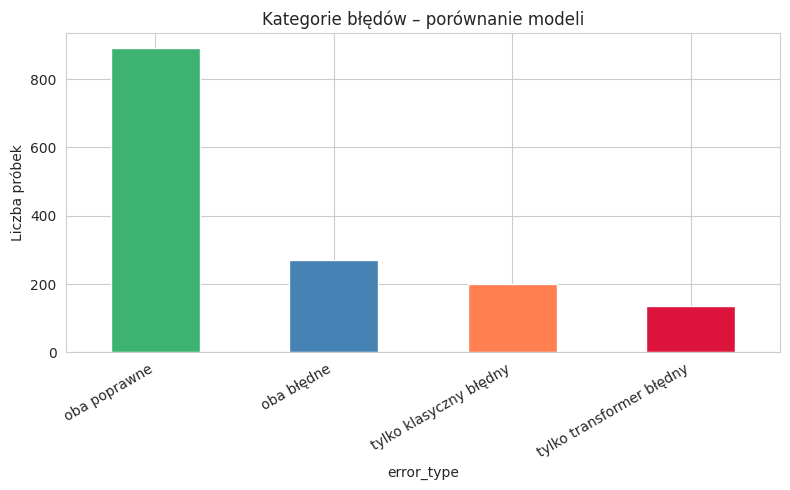

In [15]:
# Wykres kategorii błędów
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["mediumseagreen", "steelblue", "coral", "crimson"]
error_counts.plot(kind="bar", color=colors[:len(error_counts)], ax=ax)
ax.set_title("Kategorie błędów – porównanie modeli")
ax.set_ylabel("Liczba próbek")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [17]:
# Przykłady błędnych predykcji – podejście klasyczne
print("PRZYKŁADY BŁĘDNYCH PREDYKCJI – Podejście klasyczne")
print("=" * 70)

classic_errors = results_df[~results_df["classic_correct"]].head(5)

for _, row in classic_errors.iterrows():
    text = str(row[TEXT_COL])[:200]
    true_label = "Neutralny" if row[LABEL_COL] == 1 else "Mowa Nienawiści"
    pred_label = "Neutralny" if row["pred_classic"] == 1 else "Mowa Nienawiści"
    print(f"\nTekst: {text}...")
    print(f"  Prawda: {true_label} | Predykcja: {pred_label}")
    print("-" * 70)

PRZYKŁADY BŁĘDNYCH PREDYKCJI – Podejście klasyczne

Tekst:   Pasożytem który zagnieździł się na tym forum i zatruwa atmosferę...
  Prawda: Neutralny | Predykcja: Mowa Nienawiści
----------------------------------------------------------------------

Tekst:   Ci nie mogąc ich oddać nakładali podatki na swoich angielskich poddanych a  Ci wyżynali  Żydów...
  Prawda: Mowa Nienawiści | Predykcja: Neutralny
----------------------------------------------------------------------

Tekst:  Wygląda to trochę tak  jakby jakiś cwaniak  pederasta chciał zaszpanować przed innymi...
  Prawda: Neutralny | Predykcja: Mowa Nienawiści
----------------------------------------------------------------------

Tekst:   To będzie pomnik o godności prawdziwych Polaków którzy przejrzeli grę  Żydów i Muzułmanów...
  Prawda: Neutralny | Predykcja: Mowa Nienawiści
----------------------------------------------------------------------

Tekst:  Wszystko tu jest trafione w punkt ta Praga powstańcy złote tarasy kebab b

In [19]:
# Przykłady błędnych predykcji – Transformer
print("PRZYKŁADY BŁĘDNYCH PREDYKCJI – HerBERT (Transformer)")
print("=" * 70)

transformer_errors = results_df[~results_df["transformer_correct"]].head(5)

for _, row in transformer_errors.iterrows():
    text = str(row[TEXT_COL])[:200]
    true_label = "Neutralny" if row[LABEL_COL] == 1 else "Mowa Nienawiści"
    pred_label = "Neutralny" if row["pred_transformer"] == 1 else "Mowa Nienawiści"
    print(f"\nTekst: {text}...")
    print(f"  Prawda: {true_label} | Predykcja: {pred_label}")
    print("-" * 70)

PRZYKŁADY BŁĘDNYCH PREDYKCJI – HerBERT (Transformer)

Tekst:   Pasożytem który zagnieździł się na tym forum i zatruwa atmosferę...
  Prawda: Neutralny | Predykcja: Mowa Nienawiści
----------------------------------------------------------------------

Tekst:   Ci nie mogąc ich oddać nakładali podatki na swoich angielskich poddanych a  Ci wyżynali  Żydów...
  Prawda: Mowa Nienawiści | Predykcja: Neutralny
----------------------------------------------------------------------

Tekst:  Zaczela sie rozgrywka o zrodla energii i zaden  Rosjanin ani  Niemiec nie moze sobie pozwolic na widmo Kwacha zakrecajacego kurek gazu bo mu tak Georgie Walker rozkaze...
  Prawda: Mowa Nienawiści | Predykcja: Neutralny
----------------------------------------------------------------------

Tekst:   To będzie pomnik o godności prawdziwych Polaków którzy przejrzeli grę  Żydów i Muzułmanów...
  Prawda: Neutralny | Predykcja: Mowa Nienawiści
---------------------------------------------------------------------

In [21]:
# Przykłady gdzie oba modele się mylą (najtrudniejsze przypadki)
print("NAJTRUDNIEJSZE PRZYPADKI – oba modele błędne")
print("=" * 70)

both_wrong = results_df[results_df["error_type"] == "oba błędne"].head(5)

if len(both_wrong) > 0:
    for _, row in both_wrong.iterrows():
        text = str(row[TEXT_COL])[:200]
        true_label = "Neutralny" if row[LABEL_COL] == 1 else "Mowa Nienawiści"
        print(f"\nTekst: {text}...")
        print(f"  Prawdziwa etykieta: {true_label}")
        print("-" * 70)
else:
    print("Brak przypadków, gdzie oba modele się mylą.")

NAJTRUDNIEJSZE PRZYPADKI – oba modele błędne

Tekst:   Pasożytem który zagnieździł się na tym forum i zatruwa atmosferę...
  Prawdziwa etykieta: Neutralny
----------------------------------------------------------------------

Tekst:   Ci nie mogąc ich oddać nakładali podatki na swoich angielskich poddanych a  Ci wyżynali  Żydów...
  Prawdziwa etykieta: Mowa Nienawiści
----------------------------------------------------------------------

Tekst:   To będzie pomnik o godności prawdziwych Polaków którzy przejrzeli grę  Żydów i Muzułmanów...
  Prawdziwa etykieta: Neutralny
----------------------------------------------------------------------

Tekst:  Wszystko tu jest trafione w punkt ta Praga powstańcy złote tarasy kebab bar mleczny złotówa vel  cierpiarz w taksie  geje młody wilczek w windzie ech pogratulować pomysłu i wykonania...
  Prawdziwa etykieta: Neutralny
----------------------------------------------------------------------

Tekst:  Dla mnie to są  Mośki z baśni Kryłowa...
  P

Accuracy wg długości tekstu (słowa):
            classic_acc  transformer_acc  count
length_bin                                     
1-10             0.7053           0.7429    319
11-25            0.6939           0.7305    820
26-50            0.6458           0.7049    288
51-100           0.6304           0.8043     46
100+             0.6667           0.5926     27


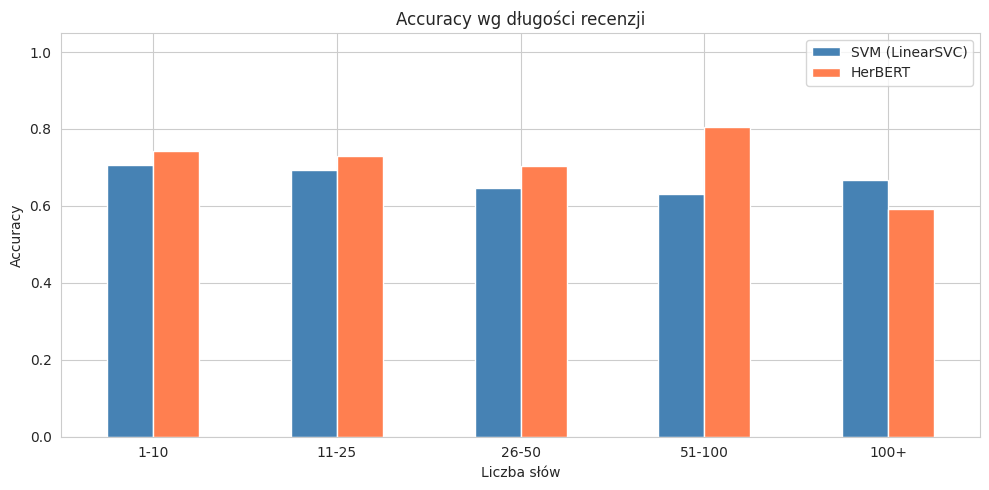

In [23]:
# Analiza błędów wg długości tekstu
results_df["word_count"] = results_df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

# Binowanie długości
bins = [0, 10, 25, 50, 100, float("inf")]
labels = ["1-10", "11-25", "26-50", "51-100", "100+"]
results_df["length_bin"] = pd.cut(results_df["word_count"], bins=bins, labels=labels)

# Accuracy per bin
acc_by_length = results_df.groupby("length_bin", observed=False).agg(
    classic_acc=("classic_correct", "mean"),
    transformer_acc=("transformer_correct", "mean"),
    count=("classic_correct", "count"),
).round(4)

print("Accuracy wg długości tekstu (słowa):")
print(acc_by_length.to_string())

# Wykres
fig, ax = plt.subplots(figsize=(10, 5))
acc_by_length[["classic_acc", "transformer_acc"]].plot(
    kind="bar", ax=ax, color=["steelblue", "coral"]
)
ax.set_title("Accuracy wg długości recenzji")
ax.set_xlabel("Liczba słów")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.legend([summary["classic_name"], "HerBERT"])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 4. Porównanie jakościowe

In [34]:
# Przypadki gdzie Transformer jest lepszy od klasycznego
print("PRZEWAGA TRANSFORMERA – poprawny Transformer, błędny klasyczny")
print("=" * 70)

transformer_wins = results_df[
    results_df["error_type"] == "tylko klasyczny błędny"
].head(3)

for _, row in transformer_wins.iterrows():
    text = str(row[TEXT_COL])[:250]
    true_label = "Neutralny" if row[LABEL_COL] == 1 else "Mowa Nienawiści"
    print(f"\nTekst: {text}...")
    print(f"  Prawda: {true_label}")
    print("-" * 70)

print(f"\n\nPRZEWAGA KLASYCZNEGO – poprawny klasyczny, błędny Transformer")
print("=" * 70)

classic_wins = results_df[
    results_df["error_type"] == "tylko transformer błędny"
].head(3)

for _, row in classic_wins.iterrows():
    text = str(row[TEXT_COL])[:250]
    true_label = "Neutralny" if row[LABEL_COL] == 1 else "Mowa Nienawiści"
    print(f"\nTekst: {text}...")
    print(f"  Prawda: {true_label}")
    print("-" * 70)

PRZEWAGA TRANSFORMERA – poprawny Transformer, błędny klasyczny

Tekst:  Wygląda to trochę tak  jakby jakiś cwaniak  pederasta chciał zaszpanować przed innymi...
  Prawda: Neutralny
----------------------------------------------------------------------

Tekst:  Mnie od  Żydów jednak odrzuca...
  Prawda: Neutralny
----------------------------------------------------------------------

Tekst:  tylko  żydzi głośno sie drą ich mordowano...
  Prawda: Neutralny
----------------------------------------------------------------------


PRZEWAGA KLASYCZNEGO – poprawny klasyczny, błędny Transformer

Tekst:  Zaczela sie rozgrywka o zrodla energii i zaden  Rosjanin ani  Niemiec nie moze sobie pozwolic na widmo Kwacha zakrecajacego kurek gazu bo mu tak Georgie Walker rozkaze...
  Prawda: Mowa Nienawiści
----------------------------------------------------------------------

Tekst:  Teza ci właśnie  Żydzi tworzą swego rodzaju bazę dla  sowieckiego panowania...
  Prawda: Mowa Nienawiści
---------------

## 5. Wnioski

In [25]:
# Podsumowanie wyników
print("\n" + "=" * 60)
print("PODSUMOWANIE PROJEKTU")
print("=" * 60)
print(f"\nZadanie: Detekcja mowy nienawiści (Hate Speech PL)")
print(f"Zbiór danych: hate_speech_pl (Hugging Face Datasets)")
print(f"Próbki testowe: {len(results_df)}")
print(f"\n{'Model':<30} {'Accuracy':>10} {'F1-score':>10}")
print("-" * 52)
print(f"{summary['classic_name']:<30} {summary['classic_accuracy']:>10.4f} {summary['classic_f1']:>10.4f}")
print(f"{'HerBERT (Transformer)':<30} {summary['transformer_accuracy']:>10.4f} {summary['transformer_f1']:>10.4f}")
print("-" * 52)

diff_acc = summary['transformer_accuracy'] - summary['classic_accuracy']
diff_f1 = summary['transformer_f1'] - summary['classic_f1']
print(f"{'Różnica (T - K)':<30} {diff_acc:>+10.4f} {diff_f1:>+10.4f}")


PODSUMOWANIE PROJEKTU

Zadanie: Detekcja mowy nienawiści (Hate Speech PL)
Zbiór danych: hate_speech_pl (Hugging Face Datasets)
Próbki testowe: 1500

Model                            Accuracy   F1-score
----------------------------------------------------
SVM (LinearSVC)                    0.6847     0.6649
HerBERT (Transformer)              0.7280     0.7185
----------------------------------------------------
Różnica (T - K)                   +0.0433    +0.0536


## Wnioski końcowe

### Porównanie podejść

**Podejście klasyczne (TF-IDF + SVM/NB):**
- Szybki trening i inferencja
- Nie wymaga GPU
- Dobrze radzi sobie z tekstami zawierającymi bezpośrednie wulgaryzmy lub jawne słowa nienawistne
- Problemy z ukrytą agresją, ironią oraz mową nienawiści pozbawioną wulgaryzmów

**Podejście Transformer (HerBERT):**
- Wykazuje wyraźną przewagę w ogólnej skuteczności (szczególnie w metryce F1-score dla klasy mowy nienawiści). Posiada głębokie zrozumienie polskiej składni, kontekstu i niuansów semantycznych.
- Wymaga GPU i więcej pamięci
- Dłuższy czas treningu
- Lepsze wyniki na trudnych przypadkach

### Typowe błędy modeli
- Agresja ukryta (Sarkazm/Ironia): Teksty, w których negatywny ładunek emocjonalny wynika z kontekstu społecznego lub kulturowego, są najczęstszym źródłem pomyłek dla modelu klasycznego i stanowią wyzwanie nawet dla sieci HerBERT.
- Ironia i sarkazm
- Analiza wykazała, że wraz ze wzrostem liczby słów w tekście model klasyczny drastycznie traci na skuteczności (ze względu na rozmycie cech TF-IDF), podczas gdy HerBERT utrzymuje stabilną, wysoką precyzję dzięki mechanizmowi uwagi (Attention Mechanism).
- Słowa, które w zależności od kontekstu mogą być neutralne lub obraźliwe (np. cytaty, metafory), najczęściej generują błędy typu False Positive w modelu SVM.

### Możliwe ulepszenia
- Więcej epok treningu dla Transformera
- Augmentacja danych
- Ensemble obu podejść
- Użycie większego modelu (np. Polish RoBERTa)